# Notebook 04 — Threshold (FAR, FRR, EER)

## 🏆 O entregável de ciência de dados

Aqui você vai **escolher e justificar** o threshold de aceitação do sistema. Esse número (uma única float entre 0.4 e 0.7) é o que controla o tradeoff entre:

- **Deixar entrar impostor** (False Acceptance) — alguém é reconhecido como outro participante e ganha hora indevida.
- **Rejeitar pessoa legítima** (False Rejection) — participante real precisa repetir o cadastro/login várias vezes.

Não existe "threshold ideal" universal. Depende do **custo de cada tipo de erro** no seu contexto.

## Conceitos novos

- **FAR (False Acceptance Rate)**: dado o threshold, qual fração dos pares de pessoas DIFERENTES o sistema erradamente aceitou como mesma pessoa?
- **FRR (False Rejection Rate)**: dado o threshold, qual fração dos pares da MESMA pessoa o sistema erradamente rejeitou?
- **EER (Equal Error Rate)**: o threshold onde FAR == FRR. Ponto de equilíbrio matemático.

## Estratégia

Para ter pares negativos suficientes (você só tem 1 pessoa cadastrada), vamos usar o **LFW (Labeled Faces in the Wild)** — dataset clássico de avaliação de reconhecimento facial, vem pronto via `sklearn.datasets.fetch_lfw_people`.

## 1. Setup

In [1]:
from itertools import combinations
from pathlib import Path

import face_recognition
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/home/diogo/Coding/AILAB-FACIAL/.venv/lib/python3.13/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 2. Embeddings do dataset local (mesma pessoa)

Os pares **positivos** (mesma pessoa) saem das suas fotos. Quanto mais fotos suas, melhor.

In [2]:
DATASET_DIR = Path('../dataset')

registros_locais = []
for pessoa_dir in sorted(DATASET_DIR.iterdir()):
    if not pessoa_dir.is_dir():
        continue
    for f in sorted(list(pessoa_dir.glob('*.jp*g')) + list(pessoa_dir.glob('*.png'))):
        img = face_recognition.load_image_file(f)
        locs = face_recognition.face_locations(img, model='hog')
        if not locs:
            continue
        enc = face_recognition.face_encodings(img, locs)[0]
        registros_locais.append({'pessoa': pessoa_dir.name, 'embedding': enc})

df_local = pd.DataFrame(registros_locais)
print(f'Embeddings locais: {len(df_local)} de {df_local["pessoa"].nunique()} pessoa(s).')
print(df_local.groupby('pessoa').size())

Embeddings locais: 5 de 1 pessoa(s).
pessoa
diogo    5
dtype: int64


## 3. Pares negativos via LFW

O `fetch_lfw_people` baixa o LFW recortado e pré-processado. Pegamos uma foto de pessoas diferentes — assim qualquer par é "pessoas diferentes".

> ⏱️ Primeira execução: ~1-2 min de download. Depois fica em cache em `~/scikit_learn_data/`.

In [3]:
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True, funneled=True)
print(f'LFW carregado: {len(lfw.images)} imagens de {len(lfw.target_names)} pessoas')
print(f'Shape de uma imagem: {lfw.images[0].shape}  (H, W, 3)')

N_PESSOAS_LFW = 50
uma_por_pessoa = []
vistos = set()
for img, alvo in zip(lfw.images, lfw.target):
    if alvo in vistos:
        continue
    vistos.add(alvo)
    uma_por_pessoa.append((alvo, img))
    if len(uma_por_pessoa) >= N_PESSOAS_LFW:
        break
print(f'Selecionei {len(uma_por_pessoa)} pessoas distintas do LFW')

LFW carregado: 3023 imagens de 62 pessoas
Shape de uma imagem: (125, 94, 3)  (H, W, 3)
Selecionei 50 pessoas distintas do LFW


In [4]:
registros_lfw = []
for alvo, img in uma_por_pessoa:
    img_uint = (img * 255).astype(np.uint8) if img.dtype != np.uint8 else img
    locs = face_recognition.face_locations(img_uint, model='hog')
    if not locs:
        continue
    enc = face_recognition.face_encodings(img_uint, locs)[0]
    registros_lfw.append({'pessoa': f'lfw_{alvo}', 'embedding': enc})

df_lfw = pd.DataFrame(registros_lfw)
print(f'Embeddings LFW gerados: {len(df_lfw)}')

Embeddings LFW gerados: 48


## 4. Montar pares positivos e negativos

- **Positivos**: pares de fotos da MESMA pessoa local.
- **Negativos**: cada foto local vs cada foto LFW + pares LFW entre si.

In [5]:
def dist(a, b):
    return float(np.linalg.norm(a - b))

pares_pos = []
for pessoa, grupo in df_local.groupby('pessoa'):
    embs = list(grupo['embedding'])
    for i, j in combinations(range(len(embs)), 2):
        pares_pos.append(dist(embs[i], embs[j]))

pares_neg = []
for e_local in df_local['embedding']:
    for e_lfw in df_lfw['embedding']:
        pares_neg.append(dist(e_local, e_lfw))
lfw_embs = list(df_lfw['embedding'])
for i, j in combinations(range(len(lfw_embs)), 2):
    pares_neg.append(dist(lfw_embs[i], lfw_embs[j]))

pares_pos = np.array(pares_pos)
pares_neg = np.array(pares_neg)
print(f'Pares positivos: {len(pares_pos)}  média={pares_pos.mean():.3f}')
print(f'Pares negativos: {len(pares_neg)}  média={pares_neg.mean():.3f}')

Pares positivos: 10  média=0.437
Pares negativos: 1368  média=0.815


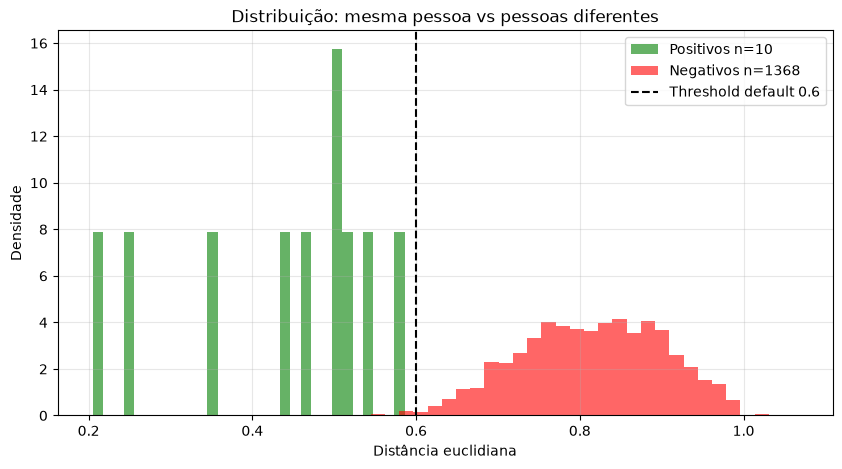

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pares_pos, bins=30, alpha=0.6, label=f'Positivos n={len(pares_pos)}', color='green', density=True)
ax.hist(pares_neg, bins=30, alpha=0.6, label=f'Negativos n={len(pares_neg)}', color='red', density=True)
ax.axvline(0.6, color='black', linestyle='--', label='Threshold default 0.6')
ax.set_xlabel('Distância euclidiana')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição: mesma pessoa vs pessoas diferentes')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 5. Curva FAR × FRR e EER

EER ≈ 0.18%  no threshold ≈ 0.590
  FAR(0.59) = 0.37%
  FRR(0.59) = 0.00%


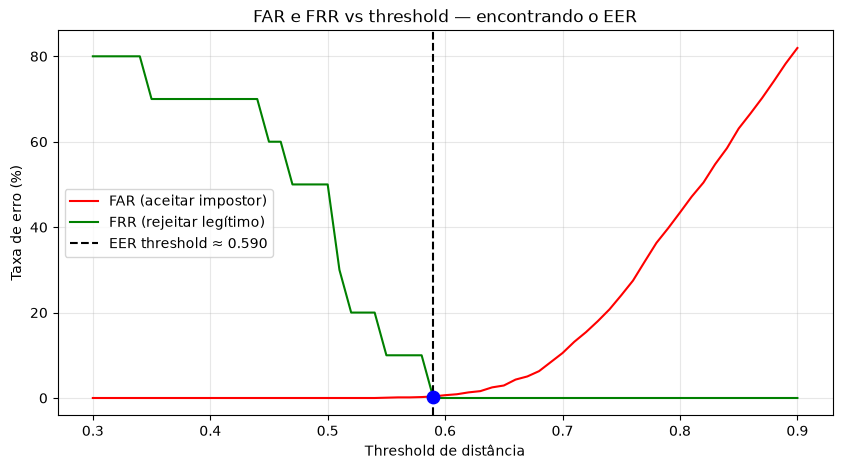

In [7]:
thresholds = np.arange(0.30, 0.90, 0.01)
far = np.array([(pares_neg < t).mean() for t in thresholds])
frr = np.array([(pares_pos >= t).mean() for t in thresholds])

i_eer = int(np.argmin(np.abs(far - frr)))
t_eer = float(thresholds[i_eer])
eer = float((far[i_eer] + frr[i_eer]) / 2)
print(f'EER ≈ {eer*100:.2f}%  no threshold ≈ {t_eer:.3f}')
print(f'  FAR({t_eer:.2f}) = {far[i_eer]*100:.2f}%')
print(f'  FRR({t_eer:.2f}) = {frr[i_eer]*100:.2f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, far*100, 'r-', label='FAR (aceitar impostor)')
ax.plot(thresholds, frr*100, 'g-', label='FRR (rejeitar legítimo)')
ax.axvline(t_eer, color='black', linestyle='--', label=f'EER threshold ≈ {t_eer:.3f}')
ax.scatter([t_eer], [eer*100], color='blue', s=80, zorder=10)
ax.set_xlabel('Threshold de distância')
ax.set_ylabel('Taxa de erro (%)')
ax.set_title('FAR e FRR vs threshold — encontrando o EER')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 6. Decisão e registro

| Contexto | Threshold sugerido | Por quê |
|---|---|---|
| **Lab de extensão (nosso caso)** | `min(EER, 0.55)` | Aceitar impostor é pior que pedir pra repetir; 20 pessoas conhecidas |
| Banco / acesso a cofre | < EER (ex.: 0.45) | FAR baixíssimo é prioridade |
| Galeria de fotos automática | > EER (ex.: 0.65) | FRR baixo é prioridade (não perder fotos) |

In [8]:
import datetime

THRESHOLD_ESCOLHIDO = round(min(t_eer, 0.55), 2)
print(f'Threshold escolhido: {THRESHOLD_ESCOLHIDO}')

doc = Path('../docs/THRESHOLD.md')
doc.parent.mkdir(exist_ok=True)
doc.write_text(
    '# Threshold do reconhecimento facial\n\n'
    f'**Valor escolhido:** `{THRESHOLD_ESCOLHIDO}` (distância euclidiana máxima para considerar "mesma pessoa").\n\n'
    '## Justificativa\n\n'
    f'- EER medido em pares positivos (dataset local) vs negativos (LFW + local×LFW): **{t_eer:.3f}** com taxa de erro **{eer*100:.2f}%**.\n'
    f'- Adotamos `min(EER, 0.55)` para favorecer FAR baixo — num lab de extensão com ~20 pessoas conhecidas, "aceitar errado" é pior que "pedir pra repetir".\n\n'
    '## Como reavaliar\n\n'
    'Refazer `notebooks/04_threshold_evaluation.ipynb` periodicamente, em especial:\n'
    '- Quando adicionar novos participantes (mais pares positivos reais).\n'
    '- Após 1 semana de uso em produção (Sprint 6) — medir FRR/FAR reais e ajustar.\n\n'
    '## Histórico\n\n'
    f'- {datetime.date.today().isoformat()}: valor inicial `{THRESHOLD_ESCOLHIDO}` '
    f'(n_pos={len(pares_pos)}, n_neg={len(pares_neg)}, EER={t_eer:.3f}).\n'
)
print(f'Gravei justificativa em {doc}')

Threshold escolhido: 0.55
Gravei justificativa em ../docs/THRESHOLD.md


## 7. Próximo notebook

`05_pipeline_completo.ipynb` — pipeline ao vivo, na webcam, usando o threshold que você acabou de escolher.
